In [1]:
import pandas as pd
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.utils import shuffle

import tensorflow as tf
from tensorflow.data import AUTOTUNE
from tensorflow.io import read_file
from tensorflow.image import decode_jpeg, resize
from tensorflow import cast, float32
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt

In [2]:
# reading already divided data

train_full = pd.read_csv("data_divided/training_full.csv")
val_full = pd.read_csv("data_divided/validation_full.csv")
test_full = pd.read_csv("data_divided/test_full.csv")

print("Files were loaded successfully")

Files were loaded successfully


In [3]:
train_full.head()

,price_numeric,Height,Width,Uniqueness,gender_guessed,gallery,painting,is_signed,age,years_selling,location,image_path
0,10673.0,64.6,62.6,Unique,unknown,gallery,other,signed,0.0,10.0,France,images_thesis\2324622_1_m.jpg
1,666.0,19.7,19.7,Unique,male,independent,other,signed,1.0,1.0,other,images_thesis\2246233_1_m.jpg
2,1275.0,45.7,35.0,Unique,male,gallery,acrylic,signed,20.0,5.0,France,images_thesis\1098924_1_m.jpg
3,972.0,18.1,15.0,Unique,male,gallery,acrylic,signed,25.0,1.0,Spain,images_thesis\2180624_1_m.jpg
4,4300.0,40.0,40.0,Unique,male,gallery,oil,not signed,3.0,3.0,United States,images_thesis\1842051_1_m.jpg


In [4]:
val_full.head()

,price_numeric,Height,Width,Uniqueness,gender_guessed,gallery,painting,is_signed,age,years_selling,location,image_path
0,1696.0,31.5,23.6,Unique,female,gallery,other,signed,6.0,3.0,other,images_thesis\2119935_1_m.jpg
1,1998.0,31.5,23.6,Unique,female,gallery,acrylic,signed,1.0,5.0,other,images_thesis\2288393_1_m.jpg
2,486.0,19.3,25.2,Unique,male,gallery,other,not signed,45.0,6.0,other,images_thesis\1630392_1_m.jpg
3,6680.0,39.4,31.9,Unique,female,independent,other,signed,0.0,3.0,France,images_thesis\2302500_1_m.jpg
4,727.0,19.7,24.0,Unique,female,gallery,oil,signed,2.0,10.0,France,images_thesis\1957158_1_m.jpg


In [5]:
test_full.head()

,price_numeric,Height,Width,Uniqueness,gender_guessed,gallery,painting,is_signed,age,years_selling,location,image_path
0,3270.0,41.3,36.6,Unique,female,independent,acrylic,signed,2.0,3.0,France,images_thesis\2162988_1_m.jpg
1,3209.0,45.7,35.0,Unique,male,independent,other,signed,9.0,6.0,France,images_thesis\1785561_1_m.jpg
2,315.0,12.0,10.7,Unique,male,independent,other,signed,0.0,4.0,other,images_thesis\2313675_1_m.jpg
3,729.0,23.8,17.9,Unique,female,gallery,other,signed,11.0,2.0,France,images_thesis\1901280_1_m.jpg
4,1002.0,31.5,15.7,Unique,unknown,gallery,acrylic,signed,1.0,2.0,France,images_thesis\2252911_1_m.jpg


In [6]:
# define safe pipeline

numeric_cols = train_full.select_dtypes(include = 'number').drop(columns = 'price_numeric').columns.to_list()   
cat_cols = train_full.select_dtypes(include = 'str').drop(columns = 'image_path').columns.to_list()

numeric_pipe = Pipeline(steps = [("scaler", StandardScaler())])

categorical_pipe = Pipeline(steps = [("onehot", OneHotEncoder(handle_unknown = "ignore", sparse_output = False))])

preprocess = ColumnTransformer(transformers = [("num", numeric_pipe, numeric_cols), 
                                              ("cat", categorical_pipe, cat_cols)], remainder = "drop") #other columns not specified will be dropped

In [7]:
print(numeric_cols)
print(cat_cols)

['Height', 'Width', 'age', 'years_selling']
['Uniqueness', 'gender_guessed', 'gallery', 'painting', 'is_signed', 'location']


In [8]:
# define x and y

X_vars = train_full.drop(columns = 'price_numeric').columns.to_list()

X_train, y_train = train_full[X_vars], train_full["price_numeric"]  # here we defined "source of truth" arrays from which 
X_val, y_val = val_full[X_vars], val_full["price_numeric"]              # custom datasets for each model type are gonna be created
X_test, y_test = test_full[X_vars], test_full["price_numeric"]          # image_path will be dropped as specified earlier in the pipeline

# fit the column transformer
X_train_mlp_prep = preprocess.fit_transform(X_train)

#apply the learned transformations for validation and test sets
X_val_mlp_prep = preprocess.transform(X_val)
X_test_mlp_prep = preprocess.transform(X_test)

# transform to numpy arrays
y_train_mlp_prep = y_train.to_numpy()
y_val_mlp_prep = y_val.to_numpy()
y_test_mlp_prep = y_test.to_numpy()

print(
    f"Size of train set X and y: {(X_train_mlp_prep.shape, y_train.shape[0])}\n"
    f"Size of validation set X and y: {(X_val_mlp_prep.shape, y_val.shape[0])}\n"
    f"Size of test set X and y: {(X_test_mlp_prep.shape, y_test.shape[0])}"
)

print("Transformations completed successfully")

Size of train set X and y: ((12543, 21), 12543)
Size of validation set X and y: ((4181, 21), 4181)
Size of test set X and y: ((4181, 21), 4181)
Transformations completed successfully


In [9]:
X_vars

['Height',
 'Width',
 'Uniqueness',
 'gender_guessed',
 'gallery',
 'painting',
 'is_signed',
 'age',
 'years_selling',
 'location',
 'image_path']

In [10]:
#set seed

tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

In [11]:
#-------------------------------------------------------------------------------------
# Define function to build MLP, it will allow not to add the last layer for regression
#--------------------------------------------------------------------------------------

def build_mlp(regress = True):
    model = Sequential()
    model.add(Input(shape = (X_train_mlp_prep.shape[1], )))
    model.add(Dense(128, activation = 'relu'))
    model.add(Dense(64, activation = 'relu'))
    model.add(Dropout(0.3))
    model.add(Dense(32, activation = 'relu'))
    model.add(Dropout(0.3))
    model.add(Dense(16, activation = 'relu'))
    model.add(Dense(8))

    # change parameter to False if the MLP is gonna be used for multimodal setup
    if regress == True:
        model.add(Dense(1))

    return model

    

In [12]:
#-------------------------------------------------------------------
# Create and compile model
#-------------------------------------------------------------------

model_mlp = build_mlp()

model_mlp.compile(optimizer = Adam(learning_rate = 1e-3),
                 loss = 'mae',
                  metrics = ['mae'])

In [13]:
#-------------------------------------------------------------------
# define early stopping and train the model
#-------------------------------------------------------------------

early_stop = EarlyStopping(monitor = 'val_loss',
                          patience = 10,
                          restore_best_weights = True)

history_mlp = model_mlp.fit(X_train_mlp_prep, y_train_mlp_prep,
                       validation_data = (X_val_mlp_prep, y_val_mlp_prep),
                       epochs = 50,
                       batch_size = 30,
                       verbose = True,
                       callbacks = [early_stop],
                       shuffle = False) #already shuffled the whole training dataset

Epoch 1/50
419/419 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 2114.8589 - mae: 2114.8589 - val_loss: 2102.3357 - val_mae: 2102.3357
Epoch 2/50
419/419 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1821.6984 - mae: 1821.6984 - val_loss: 2086.4888 - val_mae: 2086.4888
Epoch 3/50
419/419 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1804.6577 - mae: 1804.6578 - val_loss: 2075.2036 - val_mae: 2075.2036
Epoch 4/50
419/419 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1793.0642 - mae: 1793.0642 - val_loss: 2069.2036 - val_mae: 2069.2036
Epoch 5/50
419/419 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1781.6768 - mae: 1781.6766 - val_loss: 2056.6357 - val_mae: 2056.6357
Epoch 6/50
419/419 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1773.9761 - mae: 1773.9761 - val_loss: 2056.8899 - val_mae: 2056.8899
Epoch 7/50
419/419 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1761.8907 - mae: 1761.8907 - val_loss: 2051.5098 - val_mae: 2051.5098
Epoch 8/50
419/419 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1760.8221 - mae: 1760.8221 - v

In [14]:
# save the model

model_mlp.save("models/mlp_full_data.keras")

In [15]:
# make predictions

y_train_pred = model_mlp.predict(X_train_mlp_prep).ravel()
y_val_pred = model_mlp.predict(X_val_mlp_prep).ravel()
y_test_pred = model_mlp.predict(X_test_mlp_prep).ravel()


392/392 ━━━━━━━━━━━━━━━━━━━━ 0s 947us/step
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 989us/step
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [16]:

def regression_metrics(y_true_train, y_pred_train,
                       y_true_val, y_pred_val,
                       y_true_test, y_pred_test):

    def compute_metrics(y_true, y_pred):
        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_true, y_pred)
        rmse_ratio = rmse / np.mean(y_true)
        mae_ratio = mae / np.mean(y_true)
        return mse, rmse, mae, rmse_ratio, mae_ratio

    # compute metrics
    train_mse, train_rmse, train_mae, train_rmse_ratio, train_mae_ratio = compute_metrics(y_true_train, y_pred_train)
    val_mse, val_rmse, val_mae, val_rmse_ratio, val_mae_ratio = compute_metrics(y_true_val, y_pred_val)
    test_mse, test_rmse, test_mae, test_rmse_ratio, test_mae_ratio = compute_metrics(y_true_test, y_pred_test)

    # print results
    print("TRAIN")
    print(f"MSE  : {train_mse:.4f}")
    print(f"RMSE : {train_rmse:.4f}")
    print(f"MAE  : {train_mae:.4f}")
    print(f"RMSE ratio : {train_rmse_ratio:.4f}")
    print(f"MAE ratio : {train_mae_ratio:.4f}")
    print()

    print("VALIDATION")
    print(f"MSE  : {val_mse:.4f}")
    print(f"RMSE : {val_rmse:.4f}")
    print(f"MAE  : {val_mae:.4f}")
    print(f"RMSE ratio : {val_rmse_ratio:.4f}")
    print(f"MAE ratio : {val_mae_ratio:.4f}")
    print()

    print("TEST")
    print(f"MSE  : {test_mse:.4f}")
    print(f"RMSE : {test_rmse:.4f}")
    print(f"MAE  : {test_mae:.4f}")
    print(f"RMSE ratio : {test_rmse_ratio:.4f}")
    print(f"MAE ratio : {test_mae_ratio:.4f}")


In [17]:
regression_metrics(y_train, y_train_pred, y_val, y_val_pred, y_test, y_test_pred)

TRAIN
MSE  : 116269095.4406
RMSE : 10782.8148
MAE  : 1648.0939
RMSE ratio : 3.4716
MAE ratio : 0.5306

VALIDATION
MSE  : 220129170.8367
RMSE : 14836.7507
MAE  : 1986.6735
RMSE ratio : 4.3803
MAE ratio : 0.5865

TEST
MSE  : 155914514.6485
RMSE : 12486.5734
MAE  : 1884.6558
RMSE ratio : 3.7404
MAE ratio : 0.5646


In [18]:
#-----------------------------------------------------------------------------------
# CNN part
#------------------------------------------------------------------------------------


#define functions to create datasets
IMG_size = (224, 224)
Batch_size = 30

def load_preprocess_image(path, price):
    bytes = read_file(path)
    img = decode_jpeg(bytes, channels = 3)
    img = resize(img, IMG_size)
    img = cast(img, float32)/255.0
    price = cast(price, float32)
    return img, price

def create_dataset(df, y):
    image_path = df["image_path"].astype(str).to_numpy()
    price = y.to_numpy().astype('float32')

    ds = tf.data.Dataset.from_tensor_slices((image_path, price))
    ds = ds.map(load_preprocess_image, num_parallel_calls = AUTOTUNE)
    ds = ds.batch(Batch_size)
    ds = ds.prefetch(AUTOTUNE)

    return ds


#apply the functions
train_cnn = create_dataset(X_train, y_train)
val_cnn = create_dataset(X_val, y_val)
test_cnn = create_dataset(X_test, y_test)

In [19]:
# check the shape

print(train_cnn.element_spec)


(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))


In [20]:
# define the function to create cnn model

def create_cnn(regress = True, size = (224, 224, 3)):   # change to regress = False for multimodal mode
    model = Sequential()
    model.add(Input(shape = size))
    
    model.add(Conv2D(32, 3, activation = "relu", padding = "same"))
    model.add(MaxPooling2D())

    model.add(Conv2D(64, 3, activation = "relu", padding = "same"))
    model.add(MaxPooling2D())

    model.add(Conv2D(128, 3, activation = "relu", padding = "same"))
    model.add(MaxPooling2D())

    model.add(GlobalAveragePooling2D())

    model.add(Dense(128, activation = "relu"))
    model.add(Dropout(0.3))
    model.add(Dense(32, activation = "relu"))
    model.add(Dropout(0.2))
    model.add(Dense(8, activation = "relu"))

    if regress == True:
        model.add(Dense(1))

    return model

In [21]:
#create and compile the model

model_cnn = create_cnn()

model_cnn.compile(optimizer = "Adam", loss = "mae", metrics = ["mae"])

In [22]:
# define early stop and run the model

stop_cnn = EarlyStopping(monitor = "val_loss", 
                    patience = 10,
                    restore_best_weights = True)

history_cnn = model_cnn.fit(train_cnn,
                       validation_data = val_cnn,
                       epochs = 50,
                       callbacks = stop_cnn,
                       shuffle = False) 

Epoch 1/50
419/419 ━━━━━━━━━━━━━━━━━━━━ 354s 840ms/step - loss: 2351.4773 - mae: 2351.4773 - val_loss: 2551.1653 - val_mae: 2551.1653
Epoch 2/50
419/419 ━━━━━━━━━━━━━━━━━━━━ 344s 821ms/step - loss: 2264.1389 - mae: 2264.1389 - val_loss: 2537.6755 - val_mae: 2537.6755
Epoch 3/50
419/419 ━━━━━━━━━━━━━━━━━━━━ 341s 815ms/step - loss: 2252.4006 - mae: 2252.4006 - val_loss: 2534.4438 - val_mae: 2534.4438
Epoch 4/50
419/419 ━━━━━━━━━━━━━━━━━━━━ 342s 815ms/step - loss: 2243.7588 - mae: 2243.7588 - val_loss: 2534.4485 - val_mae: 2534.4485
Epoch 5/50
419/419 ━━━━━━━━━━━━━━━━━━━━ 286s 681ms/step - loss: 2243.0479 - mae: 2243.0479 - val_loss: 2533.8894 - val_mae: 2533.8894
Epoch 6/50
419/419 ━━━━━━━━━━━━━━━━━━━━ 253s 604ms/step - loss: 2247.6096 - mae: 2247.6096 - val_loss: 2532.0583 - val_mae: 2532.0583
Epoch 7/50
419/419 ━━━━━━━━━━━━━━━━━━━━ 253s 602ms/step - loss: 2240.1504 - mae: 2240.1504 - val_loss: 2532.9937 - val_mae: 2532.9937
Epoch 8/50
419/419 ━━━━━━━━━━━━━━━━━━━━ 252s 602ms/step - loss

In [23]:
model_cnn.save("models/model_cnn_full.keras")

In [24]:
# make predictions

y_train_pred_cnn = model_cnn.predict(train_cnn)
y_val_pred_cnn = model_cnn.predict(val_cnn)
y_test_pred_cnn = model_cnn.predict(test_cnn)

419/419 ━━━━━━━━━━━━━━━━━━━━ 68s 163ms/step
140/140 ━━━━━━━━━━━━━━━━━━━━ 23s 162ms/step
140/140 ━━━━━━━━━━━━━━━━━━━━ 23s 165ms/step


In [25]:

regression_metrics(y_train, y_train_pred_cnn, y_val, y_val_pred_cnn, y_test, y_test_pred_cnn)


TRAIN
MSE  : 126540994.0514
RMSE : 11249.0441
MAE  : 2218.2557
RMSE ratio : 3.6217
MAE ratio : 0.7142

VALIDATION
MSE  : 230219628.1996
RMSE : 15172.9901
MAE  : 2528.1940
RMSE ratio : 4.4796
MAE ratio : 0.7464

TEST
MSE  : 168439331.8468
RMSE : 12978.4179
MAE  : 2451.9577
RMSE ratio : 3.8878
MAE ratio : 0.7345


In [26]:
#--------------------------------------------------------------------------------------
# Multimodal learning part
#---------------------------------------------------------------------------------------

#one more helper function
def load_image(path):
    img_bytes = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img_bytes, channels=3)
    img = tf.image.resize(img, IMG_size) #reuse image size defined previously
    img = tf.cast(img, tf.float32) / 255.0
    return img

# define the function to make custom dataset from tabular and image inputs

def make_multimodal_dataset(X_df, X_tab, y):
    paths = X_df["image_path"].astype(str).to_numpy()
    tab   = X_tab.astype("float32")
    price = y.to_numpy().astype("float32")


    ds = tf.data.Dataset.from_tensor_slices((paths, tab, price))

    def pack(path, tab_vec, price):
        img = load_image(path)
        return (img, tab_vec), price

    ds = ds.map(pack, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(Batch_size) #reuse the same batch size defined previously
    ds = ds.prefetch(AUTOTUNE)

    return ds

In [27]:
# make custom datasets from initial train/val/test

train_mm_ds = make_multimodal_dataset(
    X_train,
    X_train_mlp_prep,
    y_train
)

val_mm_ds = make_multimodal_dataset(
    X_val,
    X_val_mlp_prep,
    y_val
)

test_mm_ds = make_multimodal_dataset(
    X_test,
    X_test_mlp_prep,
    y_test
)

In [28]:
# create mlp and cnn models objects without regression head

mlp_multi = build_mlp(regress = False)
cnn_multi = create_cnn(regress = False)

In [29]:
# function to build fusion model

def build_fusion(mlp, #mlp model without regression head
                 cnn, #cnn without head
                 tab_input_dim,
                img_input_dim = (224, 224, 3)):

    # Input layers
    img_input = Input(shape = img_input_dim, name = "img_input")
    tab_input = Input(shape = (tab_input_dim, ), name = "tab_input")

    #passing inputs through previously created models
    img_features = cnn(img_input)
    tab_features = mlp(tab_input)
    

    #concatenation layer
    combined = Concatenate(name = "fusion")([img_features, tab_features])

    x = Dense(64, activation = "relu")(combined)
    x = Dropout(0.3)(x)
    x = Dense(32, activation = "relu")(x)
    x = Dropout(0.3)(x)
    x = Dense(8, activation = "relu")(x)

    #output layer
    output = Dense(1, name = "price")(x)

    model = Model(inputs = [img_input, tab_input], outputs = output)

    return model

# create the model

fusion_model = build_fusion(
    mlp = mlp_multi,
    cnn = cnn_multi,
    tab_input_dim=X_train_mlp_prep.shape[1]
)
    

In [30]:
# compile the model

fusion_model.compile(optimizer = "Adam",
                     loss = "mae", 
                    metrics = ['mae', 'mse'])


In [31]:
fusion_stop = EarlyStopping(monitor = "val_loss", 
                            patience = 10,
                            restore_best_weights = True)

fusion_history = fusion_model.fit(train_mm_ds,
                                 validation_data = val_mm_ds, 
                                 callbacks = fusion_stop,
                                 epochs = 50,
                                 shuffle = False)

Epoch 1/50
419/419 ━━━━━━━━━━━━━━━━━━━━ 256s 603ms/step - loss: 2120.5715 - mae: 2120.5715 - mse: 122664568.0000 - val_loss: 2112.7124 - val_mae: 2112.7124 - val_mse: 223968432.0000
Epoch 2/50
419/419 ━━━━━━━━━━━━━━━━━━━━ 254s 606ms/step - loss: 1857.9214 - mae: 1857.9214 - mse: 119178576.0000 - val_loss: 2082.1523 - val_mae: 2082.1523 - val_mse: 223026688.0000
Epoch 3/50
419/419 ━━━━━━━━━━━━━━━━━━━━ 253s 603ms/step - loss: 1837.5892 - mae: 1837.5892 - mse: 118759768.0000 - val_loss: 2064.2031 - val_mae: 2064.2031 - val_mse: 222111424.0000
Epoch 4/50
419/419 ━━━━━━━━━━━━━━━━━━━━ 252s 602ms/step - loss: 1810.4119 - mae: 1810.4119 - mse: 118163888.0000 - val_loss: 2120.9807 - val_mae: 2120.9807 - val_mse: 224294704.0000
Epoch 5/50
419/419 ━━━━━━━━━━━━━━━━━━━━ 252s 601ms/step - loss: 1812.0399 - mae: 1812.0399 - mse: 117782640.0000 - val_loss: 2064.6116 - val_mae: 2064.6116 - val_mse: 222480224.0000
Epoch 6/50
419/419 ━━━━━━━━━━━━━━━━━━━━ 261s 599ms/step - loss: 1797.6090 - mae: 1797.6090

In [32]:
fusion_model.save("models/fusion_full.keras")

In [33]:
# make predictions

y_train_pred_fus = fusion_model.predict(train_mm_ds)
y_val_pred_fus = fusion_model.predict(val_mm_ds)
y_test_pred_fus = fusion_model.predict(test_mm_ds)

419/419 ━━━━━━━━━━━━━━━━━━━━ 69s 164ms/step
140/140 ━━━━━━━━━━━━━━━━━━━━ 23s 162ms/step
140/140 ━━━━━━━━━━━━━━━━━━━━ 23s 160ms/step


In [34]:
# compute the metrics
regression_metrics(y_train, y_train_pred_fus, y_val, y_val_pred_fus, y_test, y_test_pred_fus)


TRAIN
MSE  : 116476668.8673
RMSE : 10792.4357
MAE  : 1660.9443
RMSE ratio : 3.4747
MAE ratio : 0.5347

VALIDATION
MSE  : 220133758.4389
RMSE : 14836.9053
MAE  : 2001.6187
RMSE ratio : 4.3804
MAE ratio : 0.5909

TEST
MSE  : 155571421.2445
RMSE : 12472.8273
MAE  : 1898.7843
RMSE ratio : 3.7363
MAE ratio : 0.5688


In [35]:
#------------------------ REPEAT THE ANALYSIS WITH CLEANED DATASET ----------------------

# read the data

train_clean = pd.read_csv("data_divided/training_cleaned.csv")
val_clean = pd.read_csv("data_divided/validation_cleaned.csv")
test_clean = pd.read_csv("data_divided/test_cleaned.csv")

print("Data was loaded successfully")

X_train_cl, y_train_cl = train_clean[X_vars], train_clean["price_numeric"] 
X_val_cl, y_val_cl = val_clean[X_vars], val_clean["price_numeric"]              
X_test_cl, y_test_cl = test_clean[X_vars], test_clean["price_numeric"]          

# fit the column transformer
X_train_mlp_prep_cl = preprocess.fit_transform(X_train_cl)

#apply the learned transformations for validation and test sets
X_val_mlp_prep_cl = preprocess.transform(X_val_cl)
X_test_mlp_prep_cl = preprocess.transform(X_test_cl)

# transform to numpy arrays
y_train_mlp_prep_cl = y_train_cl.to_numpy()
y_val_mlp_prep_cl = y_val_cl.to_numpy()
y_test_mlp_prep_cl = y_test_cl.to_numpy()

print(
    f"Size of train set X and y: {(X_train_mlp_prep_cl.shape, y_train_cl.shape[0])}\n"
    f"Size of validation set X and y: {(X_val_mlp_prep_cl.shape, y_val_cl.shape[0])}\n"
    f"Size of test set X and y: {(X_test_mlp_prep_cl.shape, y_test_cl.shape[0])}"
)

print("Transformations completed successfully")

Data was loaded successfully
Size of train set X and y: ((11492, 21), 11492)
Size of validation set X and y: ((3831, 21), 3831)
Size of test set X and y: ((3809, 21), 3809)
Transformations completed successfully


In [36]:
# define the model

model_mlp_cl = build_mlp()

model_mlp_cl.compile(optimizer = Adam(learning_rate = 1e-3),
                 loss = 'mae',
                  metrics = ['mae'])

In [37]:

early_stop_cl = EarlyStopping(monitor = 'val_loss',
                          patience = 10,
                          restore_best_weights = True)

history_mlp_cl = model_mlp_cl.fit(X_train_mlp_prep_cl, y_train_mlp_prep_cl,
                       validation_data = (X_val_mlp_prep_cl, y_val_mlp_prep_cl),
                       epochs = 50,
                       batch_size = 30,
                       verbose = True,
                       callbacks = [early_stop_cl],
                       shuffle = False) #already shuffled the whole training dataset

Epoch 1/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1038.1814 - mae: 1038.1814 - val_loss: 769.2585 - val_mae: 769.2585
Epoch 2/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 795.0861 - mae: 795.0861 - val_loss: 761.8504 - val_mae: 761.8504
Epoch 3/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 782.9422 - mae: 782.9422 - val_loss: 757.2036 - val_mae: 757.2036
Epoch 4/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 780.5293 - mae: 780.5293 - val_loss: 755.7148 - val_mae: 755.7148
Epoch 5/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 779.7102 - mae: 779.7102 - val_loss: 751.4454 - val_mae: 751.4454
Epoch 6/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 776.3169 - mae: 776.3169 - val_loss: 748.2267 - val_mae: 748.2267
Epoch 7/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 768.0436 - mae: 768.0436 - val_loss: 745.7280 - val_mae: 745.7280
Epoch 8/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 767.9794 - mae: 767.9794 - val_loss: 753.8691 - val_mae:

In [38]:
model_mlp_cl.save("models/model_mlp_cleaned.keras")

In [39]:
# make predictions

y_train_pred_cl = model_mlp_cl.predict(X_train_mlp_prep_cl).ravel()
y_val_pred_cl = model_mlp_cl.predict(X_val_mlp_prep_cl).ravel()
y_test_pred_cl = model_mlp_cl.predict(X_test_mlp_prep_cl).ravel()

360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 924us/step


In [40]:

regression_metrics(y_train_cl, y_train_pred_cl, y_val_cl, y_val_pred_cl, y_test_cl, y_test_pred_cl)

TRAIN
MSE  : 1118407.5747
RMSE : 1057.5479
MAE  : 687.5801
RMSE ratio : 0.5755
MAE ratio : 0.3742

VALIDATION
MSE  : 1160847.3879
RMSE : 1077.4263
MAE  : 710.9545
RMSE ratio : 0.5809
MAE ratio : 0.3833

TEST
MSE  : 1178375.0034
RMSE : 1085.5298
MAE  : 710.2331
RMSE ratio : 0.5835
MAE ratio : 0.3818


In [41]:
# CNN part
# create dataset

train_cnn_cl = create_dataset(X_train_cl, y_train_cl)
val_cnn_cl = create_dataset(X_val_cl, y_val_cl)
test_cnn_cl = create_dataset(X_test_cl, y_test_cl)


In [42]:
# create model

model_cnn_cl = create_cnn()

model_cnn_cl.compile(optimizer = "Adam", loss = "mae", metrics = ["mae"])

In [43]:
stop_cnn_cl = EarlyStopping(monitor = "val_loss", 
                    patience = 10,
                    restore_best_weights = True)

history_cnn_cl = model_cnn_cl.fit(train_cnn_cl,
                       validation_data = val_cnn_cl,
                       epochs = 50,
                       callbacks = stop_cnn_cl,
                       shuffle = False) 

Epoch 1/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 232s 598ms/step - loss: 1097.2413 - mae: 1097.2413 - val_loss: 1060.3560 - val_mae: 1060.3560
Epoch 2/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 231s 601ms/step - loss: 1048.5205 - mae: 1048.5205 - val_loss: 1042.2902 - val_mae: 1042.2902
Epoch 3/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 232s 603ms/step - loss: 1046.6223 - mae: 1046.6223 - val_loss: 1052.2164 - val_mae: 1052.2164
Epoch 4/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 232s 602ms/step - loss: 1040.7202 - mae: 1040.7202 - val_loss: 1049.8673 - val_mae: 1049.8673
Epoch 5/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 232s 604ms/step - loss: 1036.8422 - mae: 1036.8422 - val_loss: 1044.3625 - val_mae: 1044.3625
Epoch 6/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 232s 604ms/step - loss: 1036.9885 - mae: 1036.9885 - val_loss: 1050.6090 - val_mae: 1050.6090
Epoch 7/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 231s 602ms/step - loss: 1037.0380 - mae: 1037.0381 - val_loss: 1042.3341 - val_mae: 1042.3341
Epoch 8/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 233s 605ms/step - loss

In [44]:
model_cnn_cl.save("models/model_cnn_cl.keras")

In [45]:
# predict

y_train_pred_cnn_cl = model_cnn_cl.predict(train_cnn_cl)
y_val_pred_cnn_cl = model_cnn_cl.predict(val_cnn_cl)
y_test_pred_cnn_cl = model_cnn_cl.predict(test_cnn_cl)

384/384 ━━━━━━━━━━━━━━━━━━━━ 62s 162ms/step
128/128 ━━━━━━━━━━━━━━━━━━━━ 21s 165ms/step
127/127 ━━━━━━━━━━━━━━━━━━━━ 21s 163ms/step


In [46]:

regression_metrics(y_train_cl, y_train_pred_cnn_cl, y_val_cl, y_val_pred_cnn_cl, y_test_cl, y_test_pred_cnn_cl)


TRAIN
MSE  : 1971048.3797
RMSE : 1403.9403
MAE  : 1017.5164
RMSE ratio : 0.7640
MAE ratio : 0.5537

VALIDATION
MSE  : 2021747.6200
RMSE : 1421.8817
MAE  : 1031.4975
RMSE ratio : 0.7666
MAE ratio : 0.5561

TEST
MSE  : 2074088.8467
RMSE : 1440.1697
MAE  : 1040.0276
RMSE ratio : 0.7741
MAE ratio : 0.5590


In [47]:
#------------------------------------------Fusion model-----------------------------------

# prepare dataset
train_mm_ds_cl = make_multimodal_dataset(
    X_train_cl,
    X_train_mlp_prep_cl,
    y_train_cl
)

val_mm_ds_cl = make_multimodal_dataset(
    X_val_cl,
    X_val_mlp_prep_cl,
    y_val_cl
)

test_mm_ds_cl = make_multimodal_dataset(
    X_test_cl,
    X_test_mlp_prep_cl,
    y_test_cl
)


In [48]:
mlp_multi_cl = build_mlp(regress = False)
cnn_multi_cl = create_cnn(regress = False)

fusion_model_cl = build_fusion(
    mlp = mlp_multi_cl,
    cnn = cnn_multi_cl,
    tab_input_dim=X_train_mlp_prep_cl.shape[1]
)

In [49]:
fusion_model_cl.compile(optimizer = "Adam",
                     loss = "mae", 
                    metrics = ['mae', 'mse'])

In [50]:
fusion_stop_cl = EarlyStopping(monitor = "val_loss", 
                            patience = 10,
                            restore_best_weights = True)

fusion_history_cl = fusion_model_cl.fit(train_mm_ds_cl,
                                 validation_data = val_mm_ds_cl, 
                                 callbacks = fusion_stop_cl,
                                 epochs = 50,
                                 shuffle = False)

Epoch 1/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 234s 601ms/step - loss: 980.4689 - mae: 980.4689 - mse: 1943187.8750 - val_loss: 781.7126 - val_mae: 781.7126 - val_mse: 1313622.6250
Epoch 2/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 231s 602ms/step - loss: 827.6931 - mae: 827.6930 - mse: 1428543.8750 - val_loss: 865.3027 - val_mae: 865.3027 - val_mse: 1660738.0000
Epoch 3/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 231s 601ms/step - loss: 814.4092 - mae: 814.4092 - mse: 1407522.2500 - val_loss: 773.9649 - val_mae: 773.9649 - val_mse: 1315054.7500
Epoch 4/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 232s 605ms/step - loss: 804.7836 - mae: 804.7836 - mse: 1392873.7500 - val_loss: 791.8035 - val_mae: 791.8035 - val_mse: 1396456.3750
Epoch 5/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 234s 610ms/step - loss: 795.7468 - mae: 795.7468 - mse: 1357988.1250 - val_loss: 783.7525 - val_mae: 783.7525 - val_mse: 1385328.7500
Epoch 6/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 232s 604ms/step - loss: 783.5810 - mae: 783.5810 - mse: 1315832.1250 - val_loss: 788.9391 

In [51]:
y_train_pred_fus_cl = fusion_model_cl.predict(train_mm_ds_cl)
y_val_pred_fus_cl = fusion_model_cl.predict(val_mm_ds_cl)
y_test_pred_fus_cl = fusion_model_cl.predict(test_mm_ds_cl)

384/384 ━━━━━━━━━━━━━━━━━━━━ 64s 165ms/step
128/128 ━━━━━━━━━━━━━━━━━━━━ 21s 162ms/step
127/127 ━━━━━━━━━━━━━━━━━━━━ 21s 163ms/step


In [52]:

regression_metrics(y_train_cl, y_train_pred_fus_cl, y_val_cl, y_val_pred_fus_cl, y_test_cl, y_test_pred_fus_cl)


TRAIN
MSE  : 1241190.3690
RMSE : 1114.0872
MAE  : 732.7461
RMSE ratio : 0.6062
MAE ratio : 0.3987

VALIDATION
MSE  : 1266733.5982
RMSE : 1125.4926
MAE  : 749.2053
RMSE ratio : 0.6068
MAE ratio : 0.4039

TEST
MSE  : 1288982.4789
RMSE : 1135.3336
MAE  : 750.1423
RMSE ratio : 0.6103
MAE ratio : 0.4032


In [53]:
fusion_model_cl.save("models/fusion_clean.keras")

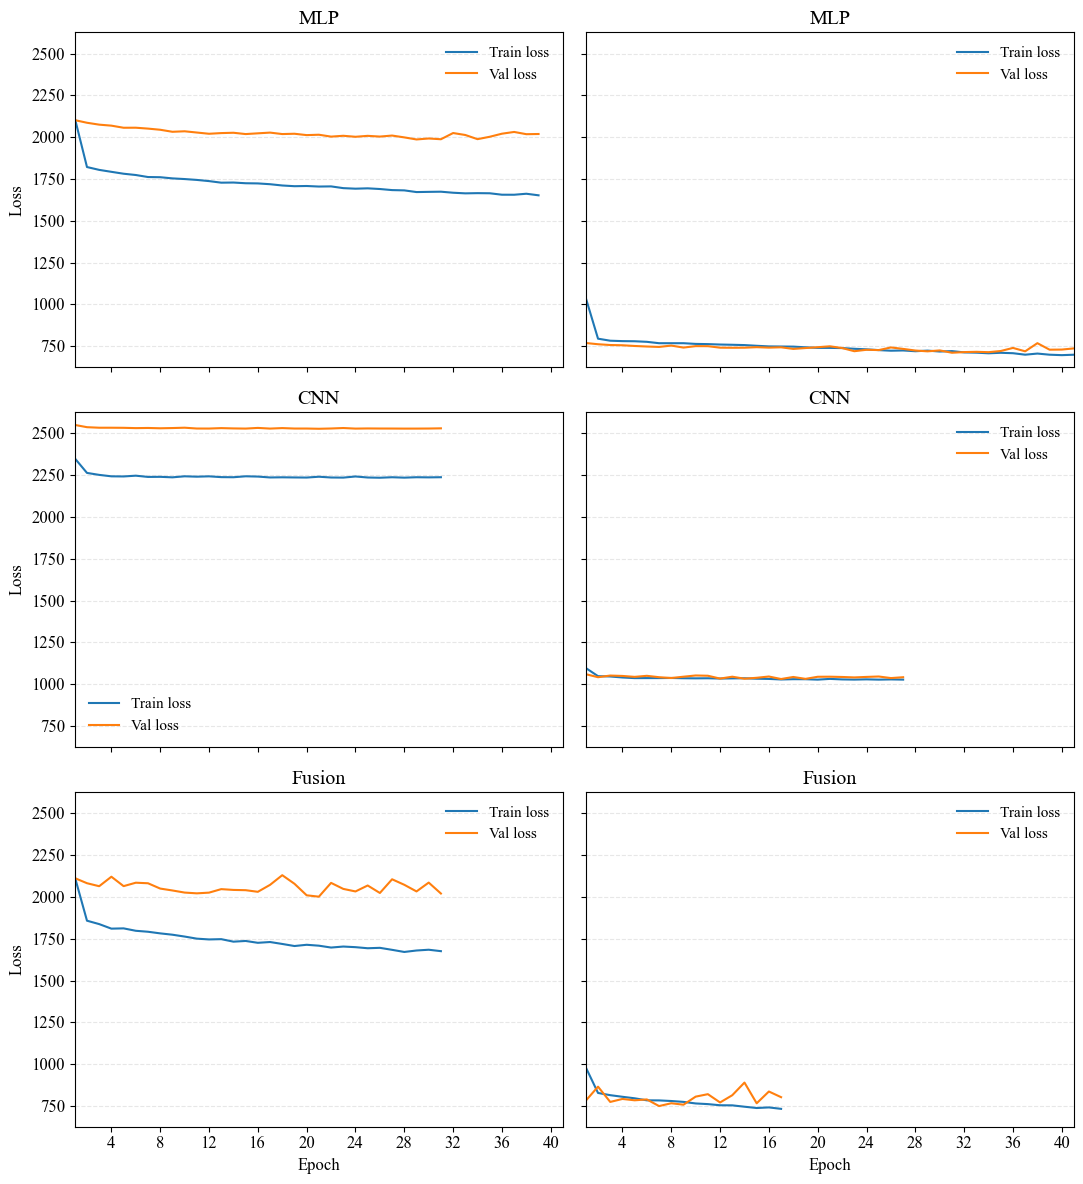

In [54]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator

# ---- Styling ----
mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['font.size'] = 12

metric = "loss"          # change to "accuracy" if needed
val_metric = f"val_{metric}"

fig, axes = plt.subplots(
    nrows=3, ncols=2,
    figsize=(11, 12),
    sharey='row',
    sharex=True           # <-- ensures identical x-axis size
)

left_histories = [
    ("MLP", history_mlp),
    ("CNN", history_cnn),
    ("Fusion", fusion_history)
]

right_histories = [
    ("MLP", history_mlp_cl),
    ("CNN", history_cnn_cl),
    ("Fusion", fusion_history_cl)
]

# ---- Find the maximum number of epochs across all models ----
all_histories = [h for _, h in left_histories + right_histories]
max_epochs = max(len(h.history[metric]) for h in all_histories)

def plot_history(ax, title, hist):
    h = hist.history
    epochs = list(range(1, len(h[metric]) + 1))

    ax.plot(epochs, h[metric], label=f"Train {metric}")
    ax.plot(epochs, h[val_metric], label=f"Val {metric}")

    ax.set_title(title)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

    # ---- Consistent epoch ticks ----
    ax.set_xticks(range(1, max_epochs + 1))
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xlim(1, max_epochs)

    ax.legend(frameon=False, fontsize=11)

# ---- Plot all histories ----
for i in range(3):
    ax_l = axes[i, 0]
    ax_r = axes[i, 1]

    plot_history(ax_l, left_histories[i][0], left_histories[i][1])
    plot_history(ax_r, right_histories[i][0], right_histories[i][1])

    ax_l.set_ylabel(metric.capitalize())

axes[2, 0].set_xlabel("Epoch")
axes[2, 1].set_xlabel("Epoch")

# ---- Make ALL y-axis ranges identical ----
y_min = min(ax.get_ylim()[0] for ax in axes.flatten())
y_max = max(ax.get_ylim()[1] for ax in axes.flatten())

for ax in axes.flatten():
    ax.set_ylim(y_min, y_max)

plt.savefig("visuals/trainingloops.png")

plt.tight_layout()
plt.show()

In [55]:
import json

def save_history(history, filename):
    with open(filename, "w") as f:
        json.dump(history.history, f)

save_history(history_mlp, "history_mlp.json")
save_history(history_cnn, "history_cnn.json")
save_history(fusion_history, "fusion_history.json")
save_history(history_mlp_cl, "history_mlp_cl.json")
save_history(history_cnn_cl, "history_cnn_cl.json")
save_history(fusion_history_cl, "fusion_history_cl.json")

In [56]:
%whos

Variable                  Type                 Data/Info
--------------------------------------------------------
AUTOTUNE                  int                  -1
Adam                      type                 <class 'keras.src.optimizers.adam.Adam'>
BatchNormalization        type                 <class 'keras.src.layers.<...>tion.BatchNormalization'>
Batch_size                int                  30
ColumnTransformer         ABCMeta              <class 'sklearn.compose._<...>ormer.ColumnTransformer'>
Concatenate               type                 <class 'keras.src.layers.<...>concatenate.Concatenate'>
Conv2D                    type                 <class 'keras.src.layers.<...>olutional.conv2d.Conv2D'>
Dense                     type                 <class 'keras.src.layers.core.dense.Dense'>
Dropout                   type                 <class 'keras.src.layers.<...>ization.dropout.Dropout'>
EarlyStopping             type                 <class 'keras.src.callbac<...>_stopping.Early

In [57]:
tf_datasets = [
    name for name, obj in globals().items()
    if isinstance(obj, tf.data.Dataset)
]

print(tf_datasets)

['train_cnn', 'val_cnn', 'test_cnn', 'train_mm_ds', 'val_mm_ds', 'test_mm_ds', 'train_cnn_cl', 'val_cnn_cl', 'test_cnn_cl', 'train_mm_ds_cl', 'val_mm_ds_cl', 'test_mm_ds_cl']


In [58]:
numpy_arrays = [name for name, obj in globals().items() if isinstance(obj, np.ndarray)]

print(numpy_arrays)

['X_train_mlp_prep', 'X_val_mlp_prep', 'X_test_mlp_prep', 'y_train_mlp_prep', 'y_val_mlp_prep', 'y_test_mlp_prep', 'y_train_pred', 'y_val_pred', 'y_test_pred', 'y_train_pred_cnn', 'y_val_pred_cnn', 'y_test_pred_cnn', 'y_train_pred_fus', 'y_val_pred_fus', 'y_test_pred_fus', 'X_train_mlp_prep_cl', 'X_val_mlp_prep_cl', 'X_test_mlp_prep_cl', 'y_train_mlp_prep_cl', 'y_val_mlp_prep_cl', 'y_test_mlp_prep_cl', 'y_train_pred_cl', 'y_val_pred_cl', 'y_test_pred_cl', 'y_train_pred_cnn_cl', 'y_val_pred_cnn_cl', 'y_test_pred_cnn_cl', 'y_train_pred_fus_cl', 'y_val_pred_fus_cl', 'y_test_pred_fus_cl', 'axes']


In [59]:
for name in numpy_arrays:
    np.save(f"prepared datasets and predictions/np/{name}.npy", globals()[name])

In [60]:
for name in tf_datasets:
    globals()[name].save(f"prepared datasets and predictions/tf/{name}")

In [61]:
X_train_mlp_prep.shape

(12543, 21)